# DX 704 Week 1 Project - Portfolio Risk/Return 

<font color = 'red'> FINAL SCORE: 75/80 </font>


This week's project will build a portfolio risk and return model, and make investing recommendations for hypothetical clients.
You will collect historical data, estimate returns and risks, construct efficient frontier portfolios, and sanity check the certainty of the maximum return portfolio.

The full project description and a template notebook are available on GitHub at the following link.

https://github.com/bu-cds-dx704/dx704-project-01


Feel free to use optimization tools or libraries (such as CVXOPT or scipy.optimize) to perform any calculations required for this mini project.

### Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Imports

In [165]:
# %pip install yfinance
# %pip install cvxpy

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt 
import yfinance as yf
import cvxpy as cp

from scipy.optimize import minimize


sns.set_theme(font_scale=0.8) 
# plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.titlesize']  = 10
plt.rcParams['axes.labelsize']  = 8
plt.rcParams['lines.linewidth'] = 0.5
# plt.rcParams['lines.markersize'] = 3
plt.rcParams['axes.edgecolor']  = 'gray'
plt.rcParams['xtick.color']     = 'gray'
plt.rcParams['ytick.color'] = 'gray'
plt.rcParams['xtick.color'] = 'gray'
plt.rcParams['ytick.color'] = 'gray'
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['xtick.labelsize'] = 8

## Helper Functions

In [166]:
def get_trading_month_end_prices(ticker: list, start_date, end_date):
    """
    Downloads daily stock data and returns the last trading day of each month.

    Args:
        ticker (list of strings): A list of stock ticker symbols (e.g., ['AAPL', 'MSFT']).
        start_date (str):  start date in 'YYYY-MM-DD' format.
        end_date (str):  end date in 'YYYY-MM-DD' format.

    Returns:
        pandas.DataFrame: A DataFrame with the last trading day's prices for each month.
    """
    # Download daily historical data
    data = yf.download(ticker, auto_adjust = True, start = start_date, end = end_date)

    if data is None or data.empty:
        print(f"No data found for ticker {ticker} in the specified date range.")
        return pd.DataFrame()

    # Resample the daily data to get the last trading day of each business month
    # The 'BME' frequency stands for Business Month-End
    monthly_data = data['Close'].resample('BME').last()
    monthly_data.index.name = 'date'

    return monthly_data



## Part 1: Collect Data

Collect historical monthly price data for the last 24 months covering 6 different stocks.
The data should cover 24 consecutive months including the last month that ended before this week's material was released on Blackboard.
To be clear, if a month ends between the Blackboard release and submitting your project, you do not need to add that month.

The six different stocks must include AAPL, SPY and TSLA.
At least one of the remaining 3 tickers must start with the same letter as your last name (e.g. professor Considine could use COIN).
This is to encourage diversity in what stocks you analyze; if you discuss this project with classmates, please make sure that you pick different tickers to differentiate your work.
Do not pick stocks with fewer than 24 consecutive months of price data.

In [167]:
# YOUR CHANGES HERE
tickers = ['AAPL', 'SPY', 'TSLA', 'RTX', 'COST', 'HIMS']


In [168]:
# historical_prices_df = pd.DataFrame()

# for t in tickers:
#     ticker                  = yf.Ticker(t)
#     history                 = ticker.history(period="2y")
#     monthly_prices          = history['Close'].resample('BME').last()
#     historical_prices_df[t] = monthly_prices

# historical_prices_df.index = pd.to_datetime(historical_prices_df.index).strftime("%Y-%m-%d")

# historical_prices_df = historical_prices_df[:-1]
# historical_prices_df

In [169]:
historical_prices_df = get_trading_month_end_prices(tickers, start_date = '2023-09-20', end_date = '2025-08-31')
print(historical_prices_df.shape)

historical_prices_df
tickers = list(historical_prices_df.columns)

[*********************100%***********************]  6 of 6 completed

(24, 6)


<Axes: title={'center': 'Monthly Prices of Assets'}, ylabel='Price (USD)'>

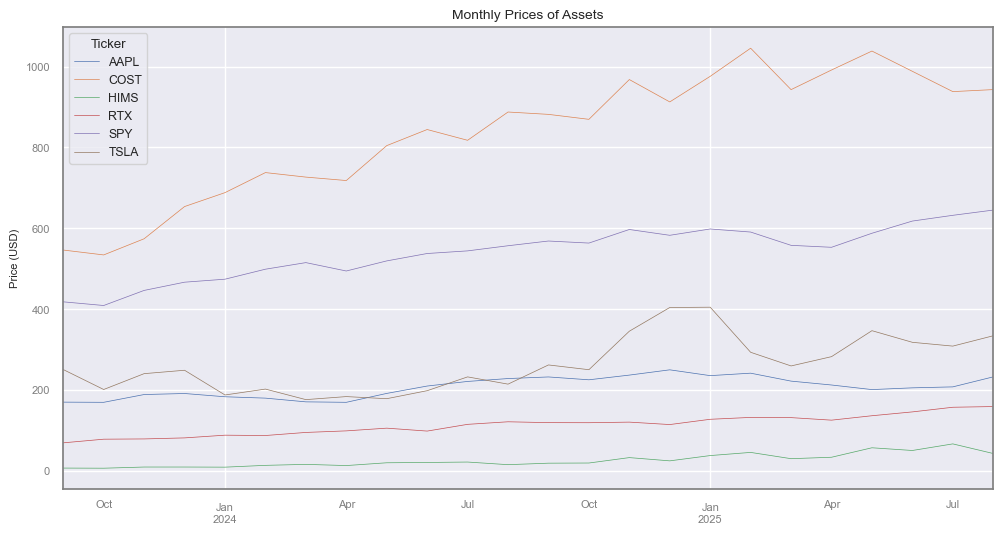

In [170]:
historical_prices_df.plot(kind='line', title='Monthly Prices of Assets', xlabel='', ylabel='Price (USD)', figsize=(12, 6))

Save the data as a TSV file named "historical_prices.tsv" and include a header row with the column names "date" and the 6 stock ticker symbols.
The date should be the last trading day of the month, so it may not be the last day of the month.
For example, the last trading day of November 2024 was 2024-11-29.
The remaining columns should contain the adjusted closing prices of the corresponding stock tickers on that day.


In [171]:
# Save the data as a TSV file named "historical_prices.tsv" and include a header row with the column names "date" and the 6 stock ticker symbols.
print(list(historical_prices_df.columns))

# # Rename the index name from 'Date' to 'date'
# historical_prices_df.index.name = 'date'

print(historical_prices_df.shape)


['AAPL', 'COST', 'HIMS', 'RTX', 'SPY', 'TSLA']
(24, 6)


In [172]:
historical_prices_df

Ticker,AAPL,COST,HIMS,RTX,SPY,TSLA
date,,,,,,
2023-09-29,169.549271,546.110779,6.290000,68.797623,417.865662,250.220001
2023-10-31,169.113556,534.008423,5.980000,77.802383,408.794373,200.839996
2023-11-30,188.355316,574.015320,8.890000,78.462563,446.135193,240.080002
2023-12-29,190.913651,653.764404,8.900000,81.024033,466.503662,248.479996
2024-01-31,182.851913,688.231384,8.580000,87.745544,473.933411,187.289993
2024-02-29,179.461273,737.855591,13.040000,86.917717,498.666534,201.880005
2024-03-29,170.257355,726.686890,15.470000,94.536461,514.973816,175.789993
2024-04-30,169.115555,718.186768,12.530000,98.404007,494.210297,183.279999
2024-05-31,191.138153,804.609558,19.420000,105.129608,519.207336,178.080002


In [173]:

historical_prices_df.to_csv("historical_prices.tsv", sep='\t', index=True)
print("Saved historical_prices.tsv")

Saved historical_prices.tsv


Submit "historical_prices.tsv" in Gradescope.

## Part 2: Calculate Historical Asset Returns

Calculate the historical asset returns based on the price data that you previously collected.

In [174]:
# historical_prices_df = pd.read_csv("historical_prices.tsv", sep='\t')
# historical_prices_df

In [175]:
# YOUR CHANGES HERE
returns_df = historical_prices_df.pct_change().dropna()
returns_df

Ticker,AAPL,COST,HIMS,RTX,SPY,TSLA
date,,,,,,
2023-10-31,-0.002570,-0.022161,-0.049285,0.130888,-0.021709,-0.197346
2023-11-30,0.113780,0.074918,0.486622,0.008485,0.091344,0.195379
2023-12-29,0.013582,0.138932,0.001125,0.032646,0.045655,0.034988
2024-01-31,-0.042227,0.052721,-0.035955,0.082957,0.015926,-0.246257
2024-02-29,-0.018543,0.072104,0.519814,-0.009434,0.052187,0.077901
2024-03-29,-0.051286,-0.015137,0.186350,0.087655,0.032702,-0.129235
2024-04-30,-0.006706,-0.011697,-0.190045,0.040911,-0.040320,0.042608
2024-05-31,0.130222,0.120335,0.549880,0.068347,0.050580,-0.028372
2024-06-28,0.095553,0.049513,0.039650,-0.068825,0.035280,0.111186


In [176]:
print(returns_df.columns, "\n")
returns_df.columns.name = None


print(returns_df.columns)

Index(['AAPL', 'COST', 'HIMS', 'RTX', 'SPY', 'TSLA'], dtype='object', name='Ticker') 

Index(['AAPL', 'COST', 'HIMS', 'RTX', 'SPY', 'TSLA'], dtype='object')


<Axes: title={'center': 'Monthly Returns of Assets'}, xlabel='date'>

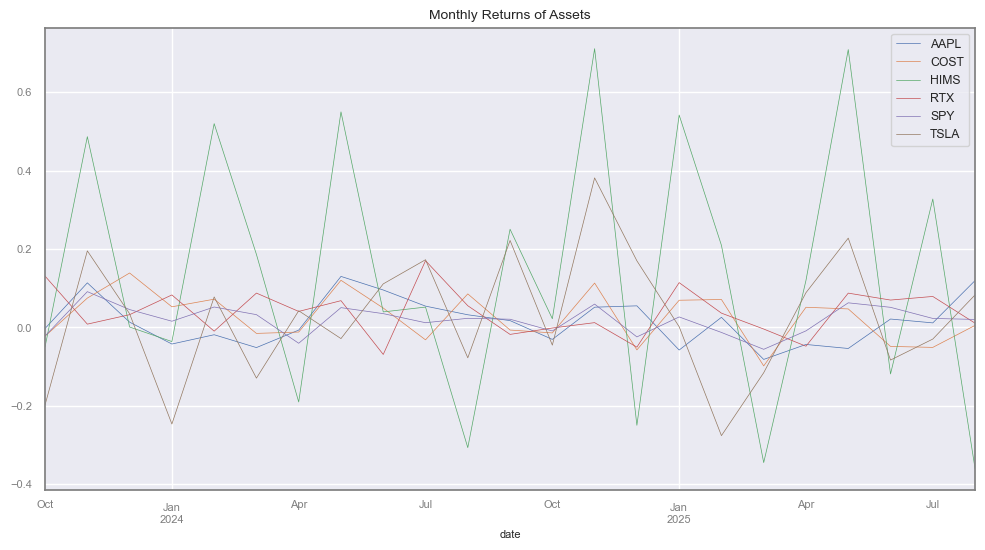

In [177]:
returns_df.plot(kind='line', title='Monthly Returns of Assets', figsize=(12, 6))

Save the data as a TSV file named "historical_returns.tsv" and include a header row with the column names "date" and the 6 stock ticker symbols.
Each row should have the date at the end of the month and the corresponding *relative* price changes.
For example, if the previous price was \$100 and the new price is \$110, the return value should be 0.10.
There should only be 23 rows of data in this file, since they are computed as the differences of 24 prices.

In [178]:
# YOUR CHANGES HERE

returns_df.to_csv("historical_returns.tsv", sep='\t')
print("Saved historical_returns.tsv")

Saved historical_returns.tsv


Submit "historical_returns.tsv" in Gradescope.

## Part 3: Estimate Returns

Estimate the expected returns for each asset using the previously calculated return data.
Just compute the average (mean) return for each asset over your data set; do not use other estimators that have been mentioned.
This will serve as your estimate of expected return for each asset.

In [179]:
# YOUR CHANGES HERE

# Calculate the mean (average) return for each asset
estimated_returns = returns_df.mean()
print(estimated_returns)

AAPL    0.015442
COST    0.025949
HIMS    0.133582
RTX     0.038656
SPY     0.019666
TSLA    0.025313
dtype: float64


In [180]:
estimated_returns_df = pd.DataFrame(estimated_returns).reset_index() 
estimated_returns_df.columns = ['asset', 'estimated_return']
estimated_returns_df

,asset,estimated_return
0,AAPL,0.015442
1,COST,0.025949
2,HIMS,0.133582
3,RTX,0.038656
4,SPY,0.019666
5,TSLA,0.025313


Save the estimated returns in a TSV file named "estimated_returns.tsv" and include a header row with the column names "asset" and "estimated_return".

In [181]:
# YOUR CHANGES HERE

estimated_returns_df.to_csv("estimated_returns.tsv", sep='\t', index = True)
print("Saved estimated_returns.tsv")

Saved estimated_returns.tsv


Submit "estimated_returns.tsv" in Gradescope.

## Part 4: Estimate Risk

Estimate the covariance matrix for the asset returns to understand how the assets move together.

In [182]:
# YOUR CHANGES HERE
estimated_variances     = returns_df.var()
estimated_covariances   = returns_df.cov()

print(estimated_variances, "\n")
print(estimated_covariances)

AAPL    0.003627
COST    0.004055
HIMS    0.110315
RTX     0.003652
SPY     0.001292
TSLA    0.026703
dtype: float64 

          AAPL      COST      HIMS       RTX       SPY      TSLA
AAPL  0.003627  0.001049  0.000182 -0.000634  0.000832  0.003254
COST  0.001049  0.004055  0.010877 -0.000230  0.001340  0.001754
HIMS  0.000182  0.010877  0.110315  0.002915  0.007739  0.021575
RTX  -0.000634 -0.000230  0.002915  0.003652  0.000197 -0.003152
SPY   0.000832  0.001340  0.007739  0.000197  0.001292  0.002421
TSLA  0.003254  0.001754  0.021575 -0.003152  0.002421  0.026703


Save the estimated covariances to a TSV file named "estimated_covariance.tsv".
The header row should have a blank column name followed by the names of the assets.
Each data row should start with the name of an asset for that row, and be followed by the individual covariances corresponding to that row and column's assets.
(This is the format of pandas's `to_csv` method with `sep="\t"` when used on a covariance matrix as computed in the examples.)

In [183]:
# YOUR CHANGES HERE

estimated_covariances.to_csv("estimated_covariance.tsv", sep='\t', index = True)
print("Saved estimated_covariance.tsv")

Saved estimated_covariance.tsv


Submit "estimated_covariance.tsv" in Gradescope.

## Part 5: Construct the Maximum Return Portfolio

Compute the maximum return portfolio based on your previously estimated risks and returns.

In [184]:
# number of assets
n = len(estimated_returns_df)
print(f'Number of assets: {n}')

# create variables to optimize
x = cp.Variable(n)
print(x)
objective = cp.Maximize(estimated_returns_df['estimated_return'].to_numpy().reshape(1, -1) @ x)
objective

Number of assets: 6
var17621


Maximize(Expression(AFFINE, UNKNOWN, (1,)))

In [185]:
# formulate linear program
prob = cp.Problem(objective,
                  [0 <= x,
                   cp.sum(x) == 1])

estimated_return_P = prob.solve()
estimated_return_P

0.13358192385782375

In [186]:
x.value.round(4)

array([0., 0., 1., 0., 0., 0.])

In [187]:
max_return_allocations_df = estimated_returns_df.copy().drop(columns=['estimated_return'])
max_return_allocations_df['allocation'] = x.value.round(4)
max_return_allocations_df

,asset,allocation
0,AAPL,0.0
1,COST,0.0
2,HIMS,1.0
3,RTX,0.0
4,SPY,0.0
5,TSLA,0.0


In [188]:
# YOUR CHANGES HERE

# asset with the highest estimated return
# max_return_asset = estimated_returns_df.loc[estimated_returns_df['estimated_return'].idxmax()]['asset']
# print("Asset with highest estimated return:", max_return_asset)


# allocations_dict = {
#     'asset': tickers,
#     'allocation': [1.0 if asset == max_return_asset else 0.0 for asset in tickers]
# }

# max_return_allocations_df = pd.DataFrame(allocations_dict)
# max_return_allocations_df

Save the maximum return portfolio in a TSV file named "maximum_return.tsv".
The header row should have two columns, "asset" and "allocation".
The allocation values should sum up to one.


In [189]:
# YOUR CHANGES HERE

max_return_allocations_df.to_csv("maximum_return.tsv", sep = '\t', index = False)
print("Saved maximum_return.tsv")

Saved maximum_return.tsv


Submit "maximum_return.tsv" in Gradescope.

## Part 6: Construct the Minimum Risk Portfolio

Compute the minimum return portfolio based on your previously estimated risks and returns.

In [190]:
# YOUR CHANGES HERE

# create variables for minimum risk optimization
x_minimum_risk = cp.Variable(n)
# print(x_minimum_risk)

objective_minimum_risk = cp.Minimize(x_minimum_risk.T @ estimated_covariances.to_numpy() @ x_minimum_risk)
objective_minimum_risk

Minimize(Expression(CONVEX, NONNEGATIVE, ()))

In [191]:
# formulate minimum risk program
prob_minimum_risk = cp.Problem(objective_minimum_risk,
                               [0 <= x_minimum_risk,
                                cp.sum(x_minimum_risk) == 1])

covariance_minimum_risk = prob_minimum_risk.solve()
covariance_minimum_risk

0.0009343019113286325

In [192]:
x_minimum_risk.value.round(4)
# print(sum(x_minimum_risk.value.round(4)))

array([ 0.1698,  0.0169, -0.    ,  0.2563,  0.557 , -0.    ])

In [193]:
estimated_return_minimum_risk = x_minimum_risk.value.T @ estimated_returns_df['estimated_return'].to_numpy()
estimated_return_minimum_risk

0.02392334449993329

In [194]:
min_risk_allocations_df = estimated_returns_df.copy().drop(columns=['estimated_return'])
min_risk_allocations_df['allocation'] = x_minimum_risk.value
min_risk_allocations_df

,asset,allocation
0,AAPL,1.697532e-01
1,COST,1.691949e-02
2,HIMS,-5.140812e-19
3,RTX,2.563300e-01
4,SPY,5.569974e-01
5,TSLA,-3.737100e-19


Save the minimum risk portfolio in a TSV file named "**minimum_risk.tsv**".
The header row should have two columns, "asset" and "allocation".
The allocation values should sum up to one.


In [195]:
# YOUR CHANGES HERE

min_risk_allocations_df.to_csv("minimum_risk.tsv", sep='\t')
print("Saved minimum_risk.tsv")

Saved minimum_risk.tsv


**Submit "minimum_risk.tsv" in Gradescope.**

## Part 7: Build Efficient Frontier Portfolios

- Compute 101 portfolios along the mean-variance efficient frontier with evenly spaced estimated returns.
- The first portfolio should be the minimum risk portfolio from part 4, and 
- the last portfolio should be the maximum return portfolio from part 3.
- The estimated return of each portfolio should be higher than the previous by one percent of the difference between the first and last portfolios. That is, the estimated return of the portfolios should be similar to `np.linspace(min_risk_return, max_return, 101)`.


### Method 2

In [196]:
# YOUR CHANGES HERE

# # Convert data to numpy arrays for optimization
# mean_returns    = returns_df.mean().values
# cov_matrix      = returns_df.cov().values

# num_assets      = len(tickers)
# bounds          = tuple((0, 1) for _ in range(num_assets))
# constraints     = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# #  portfolio functions
# def portfolio_return(weights, mean_returns):
#     return np.sum(mean_returns * weights)

# def portfolio_risk(weights, cov_matrix):
#     return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

In [197]:
# opt_method = 'SLSQP' # Sequential Least Squares Programming

# #  Minimum Risk Portfolio return and risk
# min_risk_opt = minimize(
#     fun         = portfolio_risk,
#     x0          = np.ones(num_assets) / num_assets,
#     args        = (cov_matrix,),
#     method      = opt_method,
#     bounds      = bounds,
#     constraints = constraints
# )
# min_risk_return = portfolio_return(min_risk_opt.x, mean_returns)
# min_risk_std    = portfolio_risk(min_risk_opt.x, cov_matrix)

# #  Maximum Return Portfolio return (based on Part 5)
# max_return_opt = minimize(
#     fun         = lambda w, mean_returns: -portfolio_return(w, mean_returns),
#     x0          = np.ones(num_assets) / num_assets,
#     args        = (mean_returns,),
#     method      = opt_method,
#     bounds      = bounds,
#     constraints = constraints
# )
# max_return_return = portfolio_return(max_return_opt.x, mean_returns)
# max_return_std    = portfolio_risk(max_return_opt.x, cov_matrix)

In [198]:

# # Create 101 target returns evenly spaced between min_risk_return and max_return_return
# target_returns = np.linspace(min_risk_return, max_return_return, 101)

# # Generate efficient frontier portfolios
# efficient_frontier_portfolios = []
# for i, target_return in enumerate(target_returns):
#     constraints_with_return = (
#         {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
#         {'type': 'eq', 'fun': lambda x: portfolio_return(x, mean_returns) - target_return}
#     )
#     result = minimize(
#         fun     = portfolio_risk,
#         x0      = np.ones(num_assets) / num_assets,
#         args    = (cov_matrix,),
#         method  = 'SLSQP',
#         bounds  = bounds,
#         constraints = constraints_with_return
#     )

#     if result.success:
#         weights         = result.x
#         current_return  = portfolio_return(weights, mean_returns)
#         current_risk    = portfolio_risk(weights, cov_matrix)

#         portfolio_data = {
#             'index': i,
#             'return': current_return,
#             'risk': current_risk,
#         }
#         for ticker, weight in zip(tickers, weights):
#             portfolio_data[ticker] = weight

#         efficient_frontier_portfolios.append(portfolio_data)

# ef_portfolios_df = pd.DataFrame(efficient_frontier_portfolios)
# ef_portfolios_df

In [199]:
# print('Using scipy.optimize to find efficient frontier portfolios...')
# ef_portfolios_df.to_csv("efficient_frontier.tsv", sep="\t", index = False)

### Method 1

In [200]:
# efficient frontier

ef_variances    = []
ef_returns      = []
ef_portfolios   = []

# maximum return portfolio
estimated_return_maximum_return = max(estimated_returns_df['estimated_return'])

for r in np.linspace(estimated_return_minimum_risk, estimated_return_maximum_return, 101):
    # create variables to optimize
    x_r = cp.Variable(n)

    # formulate linear program
    prob_r = cp.Problem(cp.Minimize(x_r.T @ estimated_covariances.to_numpy() @ x_r),
                        [0 <= x_r,
                         cp.sum(x_r) == 1,
                         x_r.T @ estimated_returns == r])
    ef_variances.append(prob_r.solve())
    ef_returns.append(r)
    ef_portfolios.append(x_r.value)


ef_stdvns       = np.sqrt(ef_variances)
ef_portfolios   = np.asarray(ef_portfolios)

efficient_frontier_df = pd.DataFrame({
    "index": range(101),
    "return": ef_returns,
    "risk": ef_stdvns,
})

# Adding asset allocations to the DataFrame
for i, a in enumerate(returns_df.columns):
    efficient_frontier_df[a] = [x[i] for x in ef_portfolios]

# Save the portfolios in a TSV file named "**efficient_frontier.tsv**".
# The header row should have columns "index", "return", "risk", and all the asset tickers.
# Each data row should have the portfolio index (0-100), the estimated return of the portfolio, the estimated standard deviation (not variance) of the portfolio, and all the asset allocations (which should sum to one).



Save the portfolios in a TSV file named "**efficient_frontier.tsv**".
The header row should have columns "index", "return", "risk", and all the asset tickers.
Each data row should have the portfolio index (0-100), the estimated return of the portfolio, the estimated standard deviation (not variance) of the portfolio, and all the asset allocations (which should sum to one).

In [201]:
# YOUR CHANGES HERE
print('Using cvxpy to find efficient frontier portfolios...')
efficient_frontier_df.to_csv("efficient_frontier.tsv", sep="\t", index=False)

Using cvxpy to find efficient frontier portfolios...


### Plots

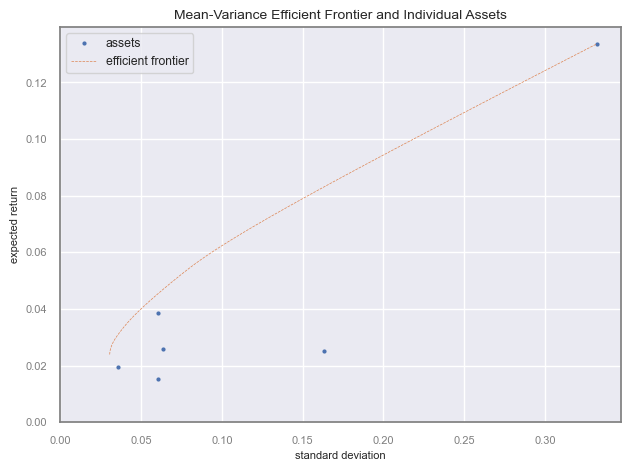

In [202]:
plt.plot(np.sqrt(estimated_variances), estimated_returns, label="assets", linestyle="none", marker="o", markersize=2)
plt.plot(np.sqrt(ef_variances), ef_returns, label="efficient frontier", linestyle="--")

plt.legend()
plt.xlabel("standard deviation")
plt.xlim(0)
plt.ylabel("expected return")
plt.ylim(0)
plt.title("Mean-Variance Efficient Frontier and Individual Assets")
plt.tight_layout()
plt.show();

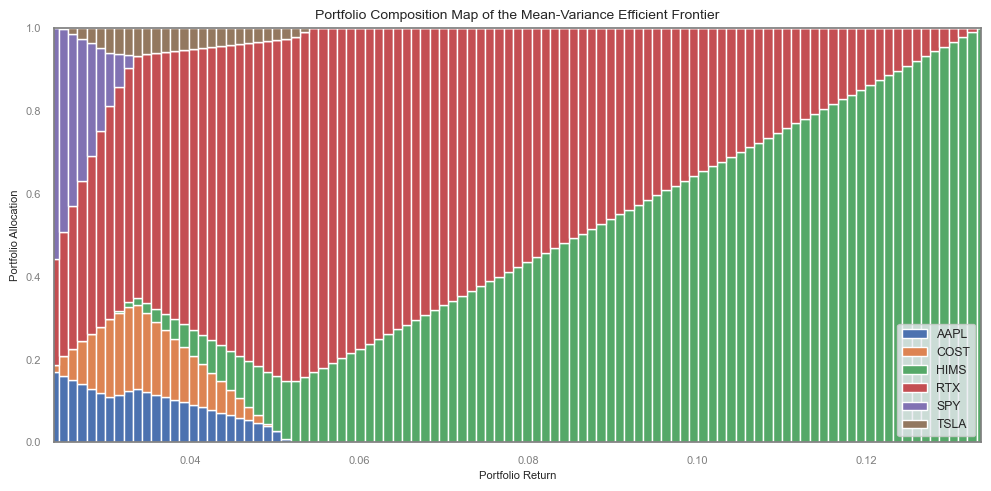

In [203]:

plt.figure(figsize=(10, 5))

ef_portfolios   = np.asarray(ef_portfolios)
bottom          = np.zeros(ef_portfolios.shape[0])
for (i, a) in enumerate(returns_df.columns):
    plt.bar(x        = ef_returns,
            height   = ef_portfolios[:,i],
            bottom   = bottom,
            label    = a,
            width    = (ef_returns[1] - ef_returns[0]))
    bottom += ef_portfolios[:,i]

plt.legend()
plt.xlabel("Portfolio Return")
plt.xlim(min(ef_returns), max(ef_returns))
plt.ylabel("Portfolio Allocation")
plt.ylim(0, 1)
plt.title("Portfolio Composition Map of the Mean-Variance Efficient Frontier")
plt.tight_layout()
plt.show();

**Submit "efficient_frontier.tsv" in Gradescope.**

## Part 8: Check Maximum Return Portfolio Stability

Check the stability of the maximum return portfolio by resampling the estimated risk/return model.

Repeat 1000 times -
1. Use `np.random.multivariate_normal` to generate 23 return samples using your previously estimated risks and returns.
2. Estimate the return of each asset using that resampled return history.
3. Check which asset had the highest return in those resampled estimates.

This procedure is a reduced and simplified version of the Michaud resampled efficient frontier procedure that takes uncertainty in the risk model into account.

In [204]:
# YOUR CHANGES HERE

num_simulations     = 1000
num_samples         = len(returns_df) # 23 months of returns

max_return_counts   = {ticker: 0 for ticker in tickers}

for _ in range(num_simulations):
    # Generate 23 return samples from a multivariate normal distribution. 
    # i can't remember wtf a multivariate normal distribution is, but 23 is the 'size' argument. 
    resampled_returns = np.random.multivariate_normal(
        estimated_returns,
        estimated_covariances.to_numpy(),
        num_samples
    )
    
    resampled_mean_returns  = np.mean(resampled_returns, axis=0)
# kind of ass backwards approach here: resample (whatever that means) , find the highest return, trace back to which stock yielded that highest return.
# then, flag it as the winner. 

    # asset with the highest mean return
    max_return_asset_index  = np.argmax(resampled_mean_returns)
    max_return_asset        = tickers[max_return_asset_index]
    print(f"Simulation {_} | Max return: {max_return_asset}, {max(resampled_mean_returns):.4f}")

    # Increment count for the asset
    max_return_counts[max_return_asset] += 1
    print(max_return_counts, "\n")

# Convert counts to probabilities
probabilities = {asset: count / num_simulations for asset, count in max_return_counts.items()}
print("Probabilities of being max return asset:", probabilities)

# print(list(probabilities.items()))
# df of probabilities
probabilities_df = pd.DataFrame(list(probabilities.items()), columns=['asset', 'probability'])
probabilities_df

Simulation 0 | Max return: HIMS, 0.1648
{'AAPL': 0, 'COST': 0, 'HIMS': 1, 'RTX': 0, 'SPY': 0, 'TSLA': 0} 

Simulation 1 | Max return: HIMS, 0.0678
{'AAPL': 0, 'COST': 0, 'HIMS': 2, 'RTX': 0, 'SPY': 0, 'TSLA': 0} 

Simulation 2 | Max return: HIMS, 0.0520
{'AAPL': 0, 'COST': 0, 'HIMS': 3, 'RTX': 0, 'SPY': 0, 'TSLA': 0} 

Simulation 3 | Max return: RTX, 0.0591
{'AAPL': 0, 'COST': 0, 'HIMS': 3, 'RTX': 1, 'SPY': 0, 'TSLA': 0} 

Simulation 4 | Max return: HIMS, 0.2101
{'AAPL': 0, 'COST': 0, 'HIMS': 4, 'RTX': 1, 'SPY': 0, 'TSLA': 0} 

Simulation 5 | Max return: RTX, 0.0443
{'AAPL': 0, 'COST': 0, 'HIMS': 4, 'RTX': 2, 'SPY': 0, 'TSLA': 0} 

Simulation 6 | Max return: HIMS, 0.2348
{'AAPL': 0, 'COST': 0, 'HIMS': 5, 'RTX': 2, 'SPY': 0, 'TSLA': 0} 

Simulation 7 | Max return: HIMS, 0.2334
{'AAPL': 0, 'COST': 0, 'HIMS': 6, 'RTX': 2, 'SPY': 0, 'TSLA': 0} 

Simulation 8 | Max return: HIMS, 0.2302
{'AAPL': 0, 'COST': 0, 'HIMS': 7, 'RTX': 2, 'SPY': 0, 'TSLA': 0} 

Simulation 9 | Max return: HIMS, 0.1335

,asset,probability
0,AAPL,0.003
1,COST,0.006
2,HIMS,0.910
3,RTX,0.058
4,SPY,0.000
5,TSLA,0.023


Save a file "**max_return_probabilities.tsv**" with the distribution of highest return assets.
The header row should have columns "asset" and "probability".
There should be a data row for each asset and its sample probability of having the highest return based on those 1000 resampled estimates.


In [205]:
# YOUR CHANGES HERE

probabilities_df.to_csv("max_return_probabilities.tsv", sep='\t', index = False)
print("Saved max_return_probabilities.tsv")

Saved max_return_probabilities.tsv


**Submit "max_return_probabilities.tsv" in Gradescope.**

## Part 9: Acknowledgments

Make a file "acknowledgments.txt" documenting any outside sources or help on this project.
If you discussed this assignment with anyone, please acknowledge them here.
If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for.
If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy.
If no acknowledgements are appropriate, just write none in the file.


Submit "acknowledgements.txt" in Gradescope.

## Part 10: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.
You do not need to provide code for data collection if you did that manually.

Submit "project.ipynb" in Gradescope.

--------------

## <font color = 'plum'>Misc. code

<font color = 'plum'> pre- Gemini/Copilot, no way in hell i would have or could have thought of any of this without asking >= 4 people (at considerable risk) and combing threads on stackoverflow.

Using the `minimize` function from the `scipy.optimize` library to find the weights for the minimum risk portfolio.

- `fun = portfolio_risk`: This specifies the objective function to be minimized, which is the `portfolio_risk` function that calculates the portfolio's standard deviation based on the asset weights and covariance matrix.
- `x0 = np.ones(num_assets) / num_assets`: sets the initial guess for the asset weights. It starts with an equal distribution of weights across all assets.
- `args = (cov_matrix,)`: additional arguments passed to the `portfolio_risk` function. In this case, it's the covariance matrix.
- `method ='SLSQP'`: specifies the optimization method to use. 'SLSQP' (Sequential Least Squares Programming) is suitable method for constrained optimization problems like this one.
- `bounds = bounds`: bounds for each asset's weight, ensuring that each weight is between 0 and 1 (inclusive).
- `constraints = constraints`: constraints on the optimization problem. In this case, the constraint is that the sum of all asset weights must equal 1.
- The `minimize` function will find the set of weights that minimizes the `portfolio_risk` function while satisfying the given bounds and constraints. The result of the optimization is stored in the `min_risk_opt` variable.

To tighten solver tolerances in **`cvxpy`**, you can pass solver-specific parameters when calling `.solve()` on your optimization problem. Here's how to do it depending on the solver you're using:

---

### ✅ General Syntax
```python
prob.solve(solver=cp.SOLVER_NAME, **solver_options)
```

---

### 🔧 Common Solvers and Their Tolerance Settings

#### **ECOS**
```python
prob.solve(solver=cp.ECOS, abstol=1e-8, reltol=1e-8, feastol=1e-8)
```

#### **SCS**
```python
prob.solve(solver=cp.SCS, eps=1e-6, max_iters=25000)
```

#### **OSQP** (for quadratic problems)
```python
prob.solve(solver=cp.OSQP, eps_abs=1e-8, eps_rel=1e-8)
```

#### **CVXOPT**
```python
prob.solve(solver=cp.CVXOPT, kktsolver='chol', feastol=1e-8)
```

---

### 📌 Notes:
- **`abstol`**, **`reltol`**, and **`feastol`** control the precision of the solution.
- Smaller values (e.g., `1e-8`) mean tighter tolerances, which can improve accuracy but may increase computation time or cause convergence issues.
- Make sure the solver you choose supports these options — not all solvers accept the same parameters.

Would you like help modifying your efficient frontier construction code to include these tighter tolerances?